# 第12课 · 矩阵不是数字表格，是变换机器——矩阵乘法与线性变换（linear transformation）

**目标**：矩阵乘向量（vector） = 对向量做旋转/拉伸；矩阵乘矩阵 = 把多个变换串起来。

**为什么对 Aurora 重要**：mel 滤波矩阵 `(M, N)` 把 FFT 频谱 `(N,)` 压缩成 mel 频谱 `(M,)`，调用的就是一次 `matvec`；DFT 的朴素实现 `dft()` 同样是 N×N 复数矩阵乘信号向量。

← **上一课**　[L11 · 向量范数](L11_norms.ipynb)

> 上节课学习了 **向量范数**：L1 / L2 / ∞ 三把尺子量向量，归一化的几何。  
> 本课将探讨 **矩阵乘法**。

## 本课剧情：矩阵是一台坐标变换机器

你见过相机的变焦功能吗？按一下，画面放大——所有的像素都乘以同一个系数，方向不变只是拉伸。这就是一个对角矩阵在做的事。

再想象旋转镜头，画面转动——每个点都绕原点旋转同一个角度。这就是旋转矩阵（rotation matrix）。

矩阵不是"数字表格"，它是一台**坐标变换机器**：
```
输入向量 x（形状 n）→ 矩阵 A（形状 m×n）→ 输出向量 y（形状 m）
```

这台机器有几个性质是线性变换专属的：
- **叠加**：`A(u + v) = Au + Av`（先加再变换 = 先变换再加）
- **缩放**：`A(cu) = c·Au`（先缩放再变换 = 先变换再缩放）
- **复合**：`A @ (B @ x) = (A @ B) @ x`（先 B 后 A = 直接用 AB）

本课你将用循环手写 `matvec`（矩阵×向量）和 `matmul`（矩阵×矩阵），理解乘法背后的"逐行点积"操作。

> **主路径**：matvec →「列的线性组合」图 → matmul → 复合。  
> 中间的长插播（线性为什么天生、点积规则从哪来…）是加深用——**先实现再展开**。  
> 手写双重循环是为了**理解**；上线/生产直接用 `A @ x` / `A @ B`。

### 插播：为什么"叠加"和"缩放"这两条性质，矩阵是"天生"就有的？

想象一台自动售货机的"配方卡"：你投入的每一种硬币数量（输入），配方卡按固定比例换算成每样商品的数量（输出）。这台机器的"性格"很老实——它对每一枚硬币都用同一套固定权重去算，不会因为你多投了几枚硬币就临时修改配方。

这种"老实"，写成数学就是：如果你把两笔硬币各自换算再相加，和你把两笔硬币先合并再换算，结果完全一样——因为配方卡做的事从头到尾都是"每种硬币数 × 固定权重，再相加"，而乘法对加法是可以分配的（`a×(x+y) = a×x + a×y`，这是小学就学过的乘法分配律）。矩阵乘法的"逐行点积"本质上就是很多个"配方卡换算"叠在一起，所以：

- **叠加**：`A(u+v) = Au+Av`——不是矩阵有什么特异功能，只是乘法分配律在每一行都成立一次，汇总起来还成立。
- **缩放**：`A(cu) = c·Au`——同理，把每个输入都乘以同一个 c，点积里每一项也跟着乘 c，可以把 c 提到外面。

来看一个具体例子而不是抽象符号：设 A=[[1,2],[3,4]]，u=[1,0]，v=[0,1]。

```
A@u = [1,3]        (取A的第一列)
A@v = [2,4]        (取A的第二列)
A@u + A@v = [3,7]

u+v = [1,1]
A@(u+v) = [1×1+2×1, 3×1+4×1] = [3,7]   ← 和上面一样！
```

这两条性质合起来，专业说法叫"线性"——但你现在知道了，它们不是矩阵额外被赋予的魔法，而是"逐行点积"这个定义 + 普通乘法分配律，自动就带出来的结果。下面代码验证一下这个具体例子。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np

A = np.array([[1.0, 2.0], [3.0, 4.0]])
u = np.array([1.0, 0.0])
v = np.array([0.0, 1.0])

lhs = A @ (u + v)          # 先加再变换
rhs = A @ u + A @ v        # 先变换再加
print('A @ (u+v)   =', lhs)
print('A@u + A@v   =', rhs)
assert np.allclose(lhs, rhs)

c = 3.0
lhs2 = A @ (c * u)
rhs2 = c * (A @ u)
print('A @ (3u)    =', lhs2)
print('3 * (A@u)   =', rhs2)
assert np.allclose(lhs2, rhs2)
print('\n✅ 叠加和缩放都验证了——这是乘法分配律的自然结果，不是矩阵的额外魔法。')


A @ (u+v)   = [3. 7.]
A@u + A@v   = [3. 7.]
A @ (3u)    = [3. 9.]
3 * (A@u)   = [3. 9.]

✅ 叠加和缩放都验证了——这是乘法分配律的自然结果，不是矩阵的额外魔法。


## 1. 矩阵 × 向量：逐行点积

矩阵 A 的形状 `(m, n)` 告诉你两件事：
- 输入：长度 n 的向量（n 个分量进来）
- 输出：长度 m 的向量（m 个分量出去）

计算方式：**输出的第 i 行 = A 的第 i 行与 x 的点积**。

手算例子：A = [[1, 2], [3, 4]]，x = [5, 6]

```
y[0] = 1×5 + 2×6 = 5 + 12 = 17
y[1] = 3×5 + 4×6 = 15 + 24 = 39
```

所以 `A @ [5, 6] = [17, 39]`。

NumPy 验证：`np.array([[1,2],[3,4]]) @ np.array([5,6])` = `array([17, 39])`。

这个"逐行点积"就是 `matvec` 函数的内部逻辑——本课你将用循环手写它。

### 插播：这个"逐行点积"的规则，到底是从哪冒出来的？

你可能会问：高中学的行列式（determinant）也涉及矩阵，那时候的乘法是这样算的吗？——其实高中的行列式是完全不同的东西（是从矩阵算出一个数，不是矩阵乘向量），这里的"矩阵×向量"是另一套规则，专门为了让矩阵能表示"坐标变换机器"而设计。

用一个类比来理解这个设计的动机：把矩阵想象成一本"配方书"，一共有 m 页（行），每一页是一个独立的配方，告诉你"要看输入的 n 个数字，分别乘上多少权重，再加起来"，作为对应输出中的一个数。第 i 页配方，只负责算出第 i 个输出，和其他页互不干扰。

这样设计有一个好处（后面第 5 节会证明）：如果矩阵 B 表示"先做一次变换"，矩阵 A 表示"再做一次变换"，那么"先 B 后 A"这整个过程，能够被打包成*另一个*矩阵 `A@B`，直接一步到位。这个"打包"的能力，只有"逐行点积"这套定义能做到——这也是数学家选择这样定义矩阵乘法的根本原因：不是任意约定，而是为了让矩阵乘法等于"函数复合"（下面第 5 节会具体证明）。

那"为什么输出是 m 维，而不是 n 维"？——答案就藏在"配方书有 m 页"这句话里：
- 矩阵有 m 行 ⟹ 有 m 本配方 ⟹ 算出 m 个输出数字。行数直接决定了输出的维度，因为每一行负责生产一个输出分量。
- 每一页配方都要读遍输入的全部 n 个数字才能算出结果（点积要求两边长度一样）⟹ 输入必须是 n 维，对应矩阵的列数。

所以"行数=输出维度，列数=输入维度"不是巧合的记忆规则，而是"每行是一份独立配方，配方要吃光全部输入"这个结构决定的——反过来"列数=输出维度"是说不通的，因为决定"有几个输出"的是"有几份配方"（行），不是"每份配方要用几个数"（列）。

## 符号入口：先看形状，再看运算

线性代数里的对象都有明确形状：向量是 `(n,)`，矩阵是 `(m, n)`，矩阵乘向量把 `(n,)` 变成 `(m,)`。每个例子先标出输入维度和输出维度，再看具体数值。

In [3]:
import numpy as np
W = np.array([[2.0, 0.0],
              [0.0, 3.0]])   # 把 x 拉伸 2 倍、y 拉伸 3 倍
x = np.array([1.0, 1.0])
print('W @ x =', W @ x)     # [2. 3.]

W @ x = [2. 3.]


## 动手观察：线代对象先看形状，再看意义

运行下面的代码，注意 `A @ v` 前后的 shape：输入 `v` 是 `(2,)`，输出还是 `(2,)`，但矩阵 `A` 的对角元素决定了每个分量被拉伸的倍数。

In [4]:
import numpy as np

v = np.array([3.0, 4.0])
A = np.array([[2.0, 0.0],
              [0.0, 0.5]])

print('v =', v, 'shape =', v.shape)
print('A =')
print(A)
print('A shape =', A.shape)
print('A @ v =', A @ v)
print('向量长度 ||v|| =', np.linalg.norm(v))


v = [3. 4.] shape = (2,)
A =
[[2.  0. ]
 [0.  0.5]]
A shape = (2, 2)
A @ v = [6. 2.]
向量长度 ||v|| = 5.0


## 代码实验：遍历几个向量，观察矩阵如何改变它们

把几个方向不同的向量送进同一个矩阵，观察输出向量的方向和长度如何随输入方向变化。

In [5]:
import numpy as np

A = np.array([[2.0, 1.0],
              [0.0, 1.0]])
vectors = [np.array([1.0, 0.0]), np.array([0.0, 1.0]), np.array([1.0, 1.0]), np.array([2.0, -1.0])]

print('A =')
print(A)
for v in vectors:
    out = A @ v
    print(f'v={v} -> A@v={out}')


A =
[[2. 1.]
 [0. 1.]]
v=[1. 0.] -> A@v=[2. 0.]
v=[0. 1.] -> A@v=[1. 1.]
v=[1. 1.] -> A@v=[3. 1.]
v=[ 2. -1.] -> A@v=[ 3. -1.]


## 2. 旋转矩阵：把向量转一个角度

### 插播：cos、sin 为什么会跑到旋转矩阵里？

先回忆高中学过的东西：在一个半径为 1 的圆（单位圆）上，从圆心出发画一条指向角度 φ 的箭头，这支箭头的箭头尖端坐标就是 `(cos φ, sin φ)`——这其实就是 cos、sin 最初的定义（直角三角形里"邻边/斜边"和"对边/斜边"，斜边长度是 1 的时候就直接等于坐标）。

现在想象你转动这支箭头——不是转动坐标系，是把箭头本身，绕圆心转过一个角度 θ。原来箭头指向角度 φ，转完之后指向角度 `φ+θ`。新的箭头尖端坐标，按同样的定义，就是 `(cos(φ+θ), sin(φ+θ))`。

高中学过的"两角和公式"（如果忘了，可以先记住结论，不影响后面用）：

```
cos(φ+θ) = cosφ·cosθ − sinφ·sinθ
sin(φ+θ) = sinφ·cosθ + cosφ·sinθ
```

现在把"半径为 1"放宽成"半径为 r"、原始点是 `(x, y) = (r·cosφ, r·sinφ)`。代入上面两个公式：

```
x' = r·cos(φ+θ) = r·cosφ·cosθ − r·sinφ·sinθ = x·cosθ − y·sinθ
y' = r·sin(φ+θ) = r·sinφ·cosθ + r·cosφ·sinθ = x·sinθ + y·cosθ
```

也就是说，任意一个点 `(x, y)` 绕原点转过角度 θ 之后，新坐标是 `(x·cosθ − y·sinθ,  x·sinθ + y·cosθ)`。把这两条式子摆成矩阵乘向量的样子：

```
[x']   [cosθ  −sinθ] [x]
[y'] = [sinθ   cosθ] [y]
```

这正是旋转矩阵 `R = [[cosθ, −sinθ], [sinθ, cosθ]]`——cos 在对角线、sin 带负号出现在右上角，不是随手排列的，而是两角和公式展开后自然摆出来的位置。

（**可选，了解复数的同学**：这其实就是复数乘法 `e^{iθ} = cosθ + i·sinθ` 的矩阵版本——用矩阵表示"乘上 e^{iθ}"，得到的正好就是这个旋转矩阵。不了解复数也完全不影响继续学习。）

**验证一下这和"列的线性组合"视角是否吻合**：矩阵第一列应该等于 `R @ [1,0]`——按公式代入 x=1,y=0，得到 `(cosθ, sinθ)`，正好是 R 的第一列；第二列应该等于 `R @ [0,1]`——代入 x=0,y=1，得到 `(−sinθ, cosθ)`，正好是 R 的第二列。两个视角对得上。

**特殊角度速查表**（白板挑战会用到，建议先记住或收藏这张表）：

| θ | 0° | 30° | 45° | 60° | 90° | 180° | 270° |
|---|---|---|---|---|---|---|---|
| cos θ | 1 | √3/2 ≈ 0.866 | √2/2 ≈ 0.707 | 1/2 | 0 | −1 | 0 |
| sin θ | 0 | 1/2 | √2/2 ≈ 0.707 | √3/2 ≈ 0.866 | 1 | 0 | −1 |

**手算示范（用 45° 走一遍完整步骤，帮你熟悉套路，白板挑战的 90° 请自己重复这个流程）**：

1. 查表：`cos45° = sin45° ≈ 0.707`
2. 代入矩阵：`R(45°) = [[0.707, −0.707], [0.707, 0.707]]`
3. 要转的向量是 `x = [3, 0]`（下面代码里会画出来）
4. 逐行点积：`y[0] = 0.707×3 + (−0.707)×0 = 2.121`；`y[1] = 0.707×3 + 0.707×0 = 2.121`
5. 所以 `R(45°) @ [3,0] ≈ [2.121, 2.121]`——下面的代码会画出这支箭头，验证它确实转到了 45° 方向。

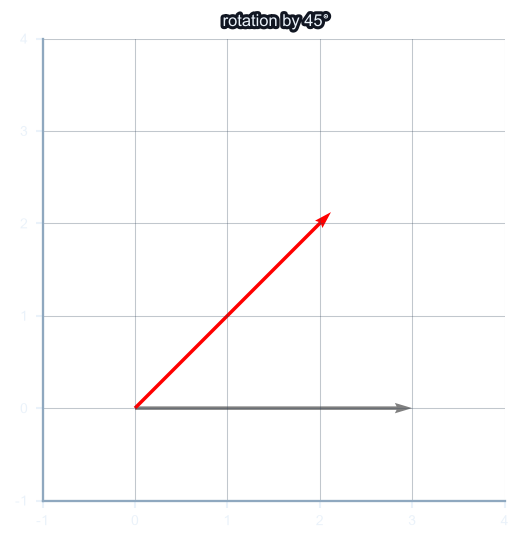

In [6]:
import matplotlib.pyplot as plt
theta = np.pi/4  # 45°
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
x = np.array([3.0, 0.0]); xr = R @ x
plt.figure(figsize=(4,4))
plt.quiver(0,0,x[0],x[1], angles='xy',scale_units='xy',scale=1,color='gray')
plt.quiver(0,0,xr[0],xr[1],angles='xy',scale_units='xy',scale=1,color='red')
plt.xlim(-1,4);plt.ylim(-1,4);plt.grid(True,alpha=.3)
plt.gca().set_aspect('equal');plt.title('rotation by 45°');plt.show()

## 3. ✏️ 你的任务：手写矩阵×向量 `matvec`

不准用 `@`，用循环展开它的计算过程。

**推理路线**：
1. 输出长度 = 矩阵行数 `m`，先建零数组：`out = np.zeros(A.shape[0])`
2. 对每个行索引 `i`，计算第 `i` 行与 `x` 的点积，存入 `out[i]`
3. 用 `np.dot(A[i], x)` 完成单行点积，等价于 Σⱼ A[i,j]·x[j]，无需写内层循环

> 🔍 **符号小贴士**：看到 `Σⱼ A[i,j]·x[j]` 这种求和符号不用紧张——它只是"把第 i 行的每个元素，和 x 里对应位置的元素相乘，再把所有乘积加起来"的缩写写法，数学家嫌打字麻烦发明的符号而已。这和你已经算过很多次的"点积"是完全同一件事，不是新概念：`np.dot(A[i], x)` 一行代码做的正是这件事。

**参考输入输出**：`A=[[1,0],[0,2]], x=[3,4]` → `[1×3+0×4, 0×3+2×4] = [3, 8]`

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写代码前，先把变量表补完整

写 `matvec` 前明确三件事：
- 输入：矩阵 `A`（形状 `(m, n)`）和向量 `x`（形状 `(n,)`）
- 关键步骤：对每个行索引 `i`，计算 `np.dot(A[i], x)` 得到输出的第 `i` 个元素
- 返回：形状 `(m,)` 的向量，与 `A @ x` 数值相同

In [7]:
def matvec(A, x):
    # ✏️ TODO: 用循环返回 A @ x（每个元素是一行与 x 的点积）
    out = np.zeros(A.shape[0])
    # for i in range(A.shape[0]):
    #     out[i] = ...
    raise NotImplementedError("TODO")


In [8]:
A = np.array([[1.0,2.0],[3.0,4.0]])
x = np.array([5.0,6.0])
try:
    result = matvec(A, x)
    print('我的 matvec:', result)
    print('numpy  A@x :', A @ x)
    assert np.allclose(result, A @ x), '应与 A@x 一致'
    print('\n✅ 通过：矩阵乘向量 = 一组点积。')
except (NotImplementedError, TypeError):
    print('⬜ matvec 未实现，请补全 TODO')


⬜ matvec 未实现，请补全 TODO


**🔗 Aurora 连接**：`src/aurora/audio/mel.py` 的 `mel_filterbank()` 返回 shape `(M, N)` 的滤波器组矩阵，`mel_spectrogram()` 实际代码是 `return power @ fb.T`，其中 `power` 形状为 `(n_frames, N)`，`fb.T` 为 `(N, M)`，结果为 `(n_frames, M)`。这等价于对每一帧单独执行 `matvec(fb, frame)`，但把帧轴放在行维度后统一批量处理，所以需要转置 `fb`。`src/aurora/audio/transforms.py` 的 `dft()` 核心是 `twiddle @ x`，N×N 复数矩阵乘信号向量——两处都是 `matvec` 的直接实例。

> 🤔 **为什么不写一个 for 循环，对每一帧都调用一次 `matvec`？**——其实那样做算出来的数值完全一样，只是慢。想象一条工厂流水线：一次只搬一箱货（循环调用 matvec）当然能把活干完，但如果把很多箱货一次性摆上传送带整体搬运（一次矩阵乘法），机器搬运的总动作更少、更快。`power @ fb.T` 就是把"很多帧"当成传送带上的一整批货，一次性算完，而不是一帧一帧地用 Python 的 for 循环慢慢搬。这不需要超出本课范围的新知识——它就是你在第 4 节要实现的 `matmul`：`power`（n_frames 行，N 列）的每一行是一帧，`fb.T`（N 行，M 列）的每一列是一个 mel 滤波器，`power @ fb.T` 的第 (frame, m) 个元素 = `power` 第 frame 行（某一帧）与 `fb.T` 第 m 列（等于 `fb` 第 m 行）的点积 = `matvec(fb, 该帧)` 的第 m 个分量。换句话说，结果矩阵的每一行，恰好就是对那一帧调用 `matvec(fb, frame)` 的结果——`matmul` 已经把"对好多个向量分别调用 matvec，再逐行摆好"这件事一次性做完了。下面用一个小例子验证这一点。

In [9]:
import numpy as np

# 模拟一个小号的 "fb" 滤波器矩阵 (M=2 个滤波器, N=3 个频率点)
fb_demo = np.array([[1.0, 0.0, 1.0],
                     [0.0, 1.0, 1.0]])

# 模拟 4 帧、每帧 3 个频率点的 "power" 矩阵
power_demo = np.array([[1.0, 2.0, 3.0],
                       [4.0, 5.0, 6.0],
                       [0.0, 1.0, 0.0],
                       [2.0, 2.0, 2.0]])

# 方法一：一帧一帧循环调用 matvec 风格的运算 (np.dot 等价于逐行点积)
loop_result = np.zeros((power_demo.shape[0], fb_demo.shape[0]))
for i, frame in enumerate(power_demo):
    loop_result[i] = np.array([np.dot(fb_demo[m], frame) for m in range(fb_demo.shape[0])])

# 方法二：一次性批量矩阵乘法（Aurora 里 mel_spectrogram 的写法）
batch_result = power_demo @ fb_demo.T

print('循环逐帧计算:\n', loop_result)
print('批量矩阵乘法:\n', batch_result)
assert np.allclose(loop_result, batch_result)
print('\n✅ 两种算法数值完全一样——批量矩阵乘法只是把循环"打包"给 numpy 去做，算得更快。')


循环逐帧计算:
 [[ 4.  5.]
 [10. 11.]
 [ 0.  1.]
 [ 4.  4.]]
批量矩阵乘法:
 [[ 4.  5.]
 [10. 11.]
 [ 0.  1.]
 [ 4.  4.]]

✅ 两种算法数值完全一样——批量矩阵乘法只是把循环"打包"给 numpy 去做，算得更快。


### 插播：逐行点积 和 列的线性组合——为什么是同一件事？

到这里你已经用"逐行点积"实现了 `matvec`。接下来你会看到另一种看待矩阵乘向量的角度："把矩阵的列当作一组积木，用输入向量的分量当权重，把积木加权拼起来"。这两种说法，乍一看像是两件不同的事，其实是同一个计算换了个角度描述。

推一遍代数就能看清楚。按定义，输出的第 i 个分量是：

```
y[i] = Σⱼ A[i,j] · x[j]   (逐行点积视角：第i行 · x)
```

现在换个顺序看这个求和：与其按"行"来分组，我们按"列 j"来分组——固定住 j，看 x[j] 对*所有*输出分量的贡献。x[j] 对第 i 个输出的贡献是 `A[i,j] · x[j]`；对所有 i 一起看，就是把 A 的第 j 列整体乘上标量 x[j]，得到向量 `x[j] · A[:,j]`。把 j=0,1,...,n-1 这些贡献向量加起来：

```
Σⱼ x[j] · A[:,j]   (列的线性组合视角)
```

这一步"加起来"，对每个分量 i 展开，正好是 `Σⱼ x[j]·A[i,j]`——和上面"逐行点积"给出的 `y[i]` 是同一个求和，只是写法的顺序换了一下（先按 j 分组、再按 i 展开，vs 先按 i 分组、再按 j 求和）。所以：

```
A @ x  =  Σⱼ x[j] · A[:,j]
```

拿一个具体例子核对：A=[[1,2],[3,4]]，x=[5,6]。

- 逐行点积：`y[0] = 1×5+2×6 = 17`，`y[1] = 3×5+4×6 = 39`
- 列的线性组合：`x[0]·A[:,0] + x[1]·A[:,1] = 5·[1,3] + 6·[2,4] = [5,15] + [12,24] = [17,39]`

两个答案一模一样。下面用代码把这两种算法都跑一遍，验证它们对任意输入都相等。

In [10]:
import numpy as np

A = np.array([[1.0, 2.0], [3.0, 4.0]])
x = np.array([5.0, 6.0])

# 视角一：逐行点积
row_view = np.array([np.dot(A[i], x) for i in range(A.shape[0])])

# 视角二：列的线性组合——用 x 的每个分量当权重，加权求和矩阵的列
col_view = np.zeros(A.shape[0])
for j in range(A.shape[1]):
    col_view += x[j] * A[:, j]

print('逐行点积视角:', row_view)
print('列的线性组合视角:', col_view)
assert np.allclose(row_view, col_view)
print('\n✅ 两种视角算出完全相同的结果——它们是同一个求和换了个分组顺序。')


逐行点积视角: [17. 39.]
列的线性组合视角: [17. 39.]

✅ 两种视角算出完全相同的结果——它们是同一个求和换了个分组顺序。


## 🎨 图示：矩阵×向量 = 列的线性组合

上一格已经用代数证明了"逐行点积"和"列的线性组合"是同一件事；这里用图把它画出来——矩阵的每一列都是坐标系里的一支箭头，输入向量 x 的每个分量告诉你"这支箭头要拉长/缩短几倍"，把缩放后的箭头首尾相接地加起来，箭头终点就是 `A@x`。

> ⚠️ **如果 `from aurora.laviz import ...` 这行在你的环境报错**（常见于包没有正确安装/导入路径问题）：不影响你理解本课内容，可以跳过这个 cell 继续往下学。文字版说明就是上一段——这张图画的是：矩阵 `[[1,2],[3,4],[5,6]]` 的两根列向量 `[1,3,5]` 和 `[2,4,6]`，分别被输入向量 `[2,1]` 的两个分量 2 和 1 拉伸，再首尾相接加起来，箭头终点就是 `mat_times_vec([[1,2],[3,4],[5,6]], [2,1])` 想要展示的 `matvec([[1,2],[3,4],[5,6]], [2,1])` 的结果。

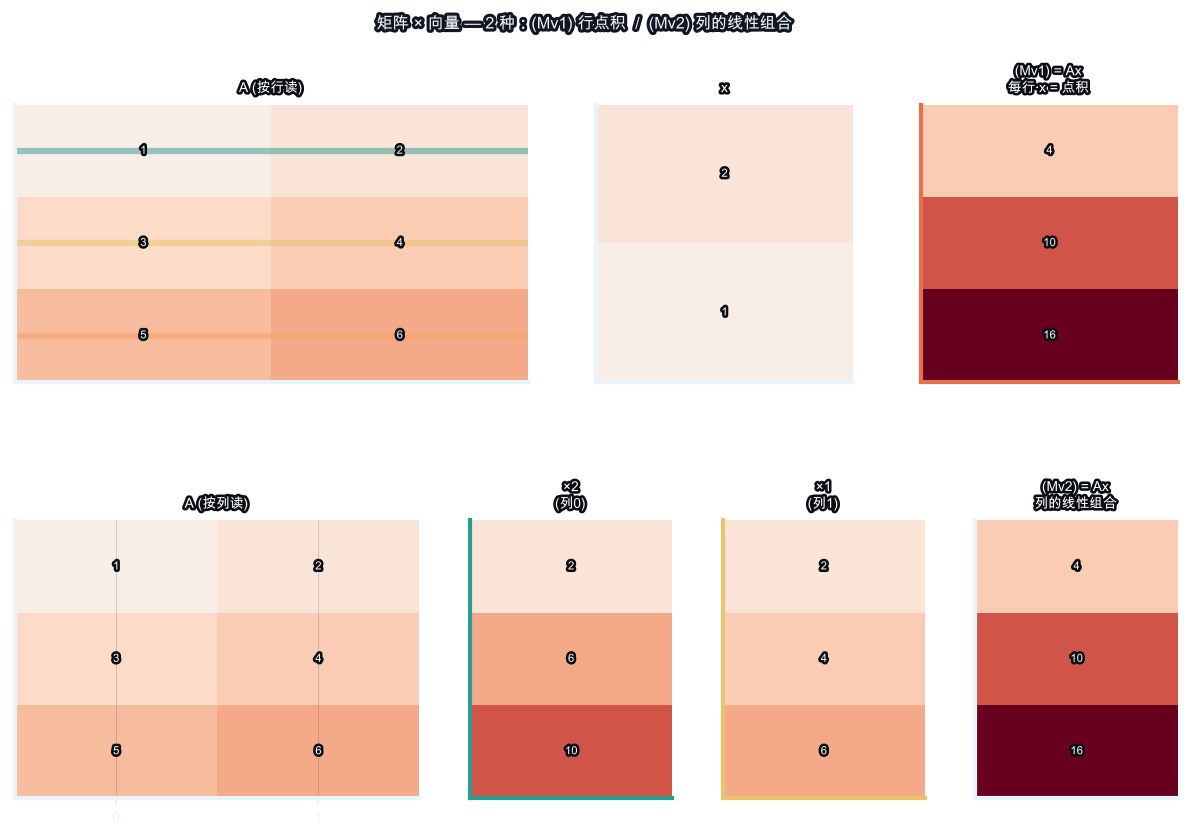

In [11]:
from aurora.laviz import style, mat_times_vec
style()
mat_times_vec([[1,2],[3,4],[5,6]],[2,1]);

In [12]:
A = np.array([[2.0, 1.0], [0.0, 1.0]])
probes = np.array([[1,0], [0,1], [1,1], [-1,2]], dtype=float)
print('矩阵 A 会怎样移动这些向量？')
for v in probes:
    out = A @ v
    print(f'{v} -> {out} | 长度 {np.linalg.norm(v):.2f} -> {np.linalg.norm(out):.2f}')


矩阵 A 会怎样移动这些向量？
[1. 0.] -> [2. 0.] | 长度 1.00 -> 2.00
[0. 1.] -> [1. 1.] | 长度 1.00 -> 1.41
[1. 1.] -> [3. 1.] | 长度 1.41 -> 3.16
[-1.  2.] -> [0. 2.] | 长度 2.24 -> 2.00


## 参数实验：对角矩阵与全1方阵

构造对角矩阵 `np.diag([2,3])`，输入 `[1,1]`，确认输出是 `[2,3]`——行 0 的权重 `[2,0]` 只取 x[0]，行 1 的权重 `[0,3]` 只取 x[1]，各维度独立缩放。再把矩阵换成全1方阵 `np.ones((2,2))`，输入同样的 `[1,1]`，观察输出变成 `[2,2]`——每一行 `[1,1]` 与 `[1,1]` 的点积 = 1+1 = 2，输出是输入所有元素之和。

> 🔍 **为什么对角矩阵会有这种"各管各的"的性质？** 不是巧合，也不是什么额外的几何魔法——直接从"逐行点积"的定义就能推出来。回忆一下：第 i 行与 x 做点积，是把第 i 行的每个元素和 x 对应位置的元素相乘再加起来。对角矩阵的第 i 行长这样：除了第 i 个位置是对角线上的数，其余全是 0。乘法里只要有一个因子是 0，那一项就贡献 0——所以点积里除了第 i 项，其余项全部自动消失，只剩下"对角线上的数 × x[i]"。这就是为什么对角矩阵表现成"逐分量独立缩放"：不是它特别聪明，是"其余元素为 0 ⟹ 点积中那些项归零"这条最朴素的乘法规则决定的。

## 4. ✏️ 进阶：手写矩阵×矩阵 `matmul`

你刚实现了矩阵×向量；矩阵×矩阵只是对 B 的每列都做一次 `matvec`。

**推理路线**：`C = A @ B`，`C[:, j] = matvec(A, B[:, j])`——对 B 的每列调用一次 `matvec`，拼起来就是 C。

**提示**：对 B 的每一列调用 `matvec(A, col)`，再把所有结果列拼成一个矩阵（自己选择拼接方式）。

### 插播：为什么矩阵×矩阵可以"拆成一列一列做 matvec"？

先看这件事到底在数学上为什么成立，而不是"课程说了照做就行"。矩阵乘矩阵 `C = A@B` 的定义（沿用"逐行点积"的思路自然扩展）：`C` 的第 i 行第 j 列这个数，是 A 的第 i 行与 B 的第 j 列做点积：

```
C[i, j] = Σₖ A[i, k] · B[k, j]
```

现在把注意力集中在"第 j 列"上，也就是固定住 j，把 `C[:, j]`（C 的整个第 j 列）看成一个向量。它的第 i 个分量是 `Σₖ A[i, k]·B[k, j]`——而这恰好就是"A 的第 i 行，与 `B[:, j]` 这个向量做点积"，也就是 `matvec(A, B[:, j])` 的第 i 个分量的定义！

所以：`C[:, j] = matvec(A, B[:, j])`——对每个固定的列号 j 都成立。这不是巧合，是把 `C=A@B` 的定义按列拆开看，直接得到的结果。这就是为什么"矩阵乘矩阵 = 对 B 的每一列分别做一次矩阵乘向量，再把结果一列列拼回去"。

**动手实现时，怎么把算出来的列拼回矩阵？** numpy 里有几种"拼列"的函数，容易混淆，来看区别：

- `np.column_stack([c1, c2, ...])`：把一组 1D 向量当作**列**拼成 2D 矩阵——这正是我们要的效果。
- `np.stack([c1, c2, ...], axis=1)`：更通用的版本，`axis=1` 表示"沿着新的第二个维度堆叠"，效果和 `column_stack` 一样。
- `np.hstack([c1, c2, ...])`：对 1D 数组来说是"水平拼接"，结果还是**一条更长的 1D 向量**，不是矩阵！这是最容易踩的坑——如果你不小心把它当成拼列的函数用，`matmul` 的输出形状会不对。
- `np.concatenate`：最底层的通用函数，需要先把每一列手动 reshape 成 `(m, 1)` 再拼，才能拼出正确形状的矩阵。

**自检技巧**：拼完之后，用 `.shape` 检查一下——`C` 应该是 `(A.shape[0], B.shape[1])`。如果形状不对（比如变成了一维），大概率是拼接函数选错了。下面用代码把这几种拼法的行为对比一遍。

In [13]:
import numpy as np

c1 = np.array([1.0, 2.0])
c2 = np.array([3.0, 4.0])

print('column_stack:\n', np.column_stack([c1, c2]), '  shape =', np.column_stack([c1, c2]).shape)
print('stack(axis=1):\n', np.stack([c1, c2], axis=1), '  shape =', np.stack([c1, c2], axis=1).shape)
print('hstack (踩坑示范，不是矩阵！):', np.hstack([c1, c2]), '  shape =', np.hstack([c1, c2]).shape)
print('concatenate + reshape:\n',
      np.concatenate([c1.reshape(-1, 1), c2.reshape(-1, 1)], axis=1),
      '  shape =', np.concatenate([c1.reshape(-1, 1), c2.reshape(-1, 1)], axis=1).shape)

# 自检：正确拼出来的矩阵形状应该是 (行数, 列数)
correct = np.column_stack([c1, c2])
assert correct.shape == (2, 2), 'column_stack 应该给出 (2,2) 的矩阵'
wrong = np.hstack([c1, c2])
assert wrong.shape == (4,), 'hstack 拼 1D 向量会拉平成一条长向量——这就是常见的坑'
print('\n✅ column_stack / stack(axis=1) 给出正确的矩阵形状；hstack 会把结果拉平，要避免。')


column_stack:
 [[1. 3.]
 [2. 4.]]   shape = (2, 2)
stack(axis=1):
 [[1. 3.]
 [2. 4.]]   shape = (2, 2)
hstack (踩坑示范，不是矩阵！): [1. 2. 3. 4.]   shape = (4,)
concatenate + reshape:
 [[1. 3.]
 [2. 4.]]   shape = (2, 2)

✅ column_stack / stack(axis=1) 给出正确的矩阵形状；hstack 会把结果拉平，要避免。


In [14]:
def matmul(A, B):
    """矩阵 × 矩阵，不准用 @，每列调用 matvec"""
    # ✏️ TODO: 对 B 的每列调用 matvec(A, col)，column_stack 拼结果
    raise NotImplementedError("TODO: 对 B 每列调用 matvec，拼成矩阵")

# 验证
A = np.array([[1.,2.],[3.,4.]])
B = np.array([[5.,6.],[7.,8.]])
try:
    C = matmul(A, B)
    print('我的 matmul:\n', C)
    print('numpy A@B:\n', A @ B)
    assert np.allclose(C, A @ B), '结果与 numpy 不一致'
    # 矩形矩阵：(3×2) @ (2×4) → (3×4)
    R = np.random.default_rng(0).standard_normal((3, 2))
    S = np.random.default_rng(1).standard_normal((2, 4))
    assert np.allclose(matmul(R, S), R @ S), '矩形矩阵 matmul 失败'
    print('\n✅ 通过：你用 matvec 手写出了矩阵乘法（包含矩形矩阵）')
except (NotImplementedError, TypeError):
    print('⬆️  先把 matmul 实现完再运行')


⬆️  先把 matmul 实现完再运行


## 5. 乘法 = 函数复合：先缩放再旋转

矩阵乘法的核心含义：`(A @ B) @ x` 与 `A @ (B @ x)` 完全相同。
也就是说，先把变换 B 作用于 x，再把变换 A 作用于结果；等价于先把 B 和 A **复合成一个矩阵** `A @ B`，再直接作用于 x。

这就是为什么矩阵乘法是**函数复合**（function composition）。

### 插播：把矩阵想成"信号处理黑盒"——为什么叫"复合"？

想象两台机器摆成一条流水线：先进机器 B，出来的半成品再送进机器 A。`B@x` 就是"信号 x 通过机器 B 之后的样子"；`A@(B@x)` 就是"半成品再通过机器 A 之后的样子"。

现在问：能不能把 B 和 A 这两台机器焊接成一台新机器，直接吃进 x，一步就吐出和"先过 B 再过 A"完全一样的结果？——答案是可以，这台"焊接后的新机器"，正是矩阵 `A@B`。这也是"矩阵乘法"这个操作为什么被叫作**函数复合**（function composition）：它把"先做一件事，再做另一件事"这两步操作，预先计算好、打包成了"一步到位"的单个矩阵。

**这和"逐个应用"比起来，计算量有什么区别？** 如果你只需要对*一个*向量 x 做这次运算，其实"先算 B@x 再算 A@(...)"往往比"先算出 A@B 这整个矩阵，再拿它乘 x"更省——因为算 `A@B` 本身要花不少功夫（一个 m×k 矩阵乘 k×n 矩阵），比直接对一个向量做两次 matvec 贵得多。但如果 A 和 B 这套组合要反复用在*很多个*不同的输入向量上（比如对上千帧音频都做"先 B 再 A"这个变换），那么提前把 `A@B` 算好一次、之后每个向量都直接乘这一个焊接好的矩阵，就比每次都乘两遍要划算——这就是"复合"在工程上的意义：一次性付出，换来后续重复使用时的效率。

In [15]:
import numpy as np

# 旋转矩阵 R：逆时针旋转 45°
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# 缩放矩阵 S：x 轴拉伸 2 倍，y 轴不变
S = np.array([[2.0, 0.0],
              [0.0, 1.0]])

x = np.array([1.0, 0.0])

# 方法 A：逐步施加 —— 先缩放，再旋转
step_by_step = R @ (S @ x)

# 方法 B：复合成一个矩阵，再施加
composed = (R @ S) @ x

print("先缩放再旋转（逐步）:", step_by_step)
print("先复合再施加（一矩阵）:", composed)
assert np.allclose(step_by_step, composed), "两路结果应完全相同"
print("✅ (R@S)@x == R@(S@x)：矩阵乘法就是函数复合")
print("复合矩阵 R@S =\n", R @ S)
print("它把先缩放再旋转打包成了一个变换。")


先缩放再旋转（逐步）: [1.41421356 1.41421356]
先复合再施加（一矩阵）: [1.41421356 1.41421356]
✅ (R@S)@x == R@(S@x)：矩阵乘法就是函数复合
复合矩阵 R@S =
 [[ 1.41421356 -0.70710678]
 [ 1.41421356  0.70710678]]
它把先缩放再旋转打包成了一个变换。


### 插播：`(A@B)@x == A@(B@x)`——这为什么总是成立？

上面代码验证了具体数字下两边相等，但"总是成立"需要从定义直接推出来，而不是只靠一个例子让人相信。跟着"逐行点积"的定义走一遍：

`(A@B)@x` 的第 i 个分量，按"逐行点积"定义，是 `A@B` 的第 i 行与 x 的点积：

```
[(A@B)@x][i] = Σⱼ (A@B)[i,j] · x[j]
```

而 `(A@B)[i,j]` 本身也是按点积定义的（A 的第 i 行与 B 的第 j 列）：`(A@B)[i,j] = Σₖ A[i,k]·B[k,j]`。代进去：

```
[(A@B)@x][i] = Σⱼ ( Σₖ A[i,k]·B[k,j] ) · x[j]
             = Σⱼ Σₖ A[i,k]·B[k,j]·x[j]
```

这是一个"双重求和"，交换一下 j 和 k 的求和顺序（先按 k 分组，对每个 k，把 j 那层求和先做完）：

```
             = Σₖ A[i,k] · ( Σⱼ B[k,j]·x[j] )
```

括号里的 `Σⱼ B[k,j]·x[j]` 正是 `B@x` 的第 k 个分量。所以：

```
[(A@B)@x][i] = Σₖ A[i,k] · (B@x)[k] = [A@(B@x)][i]
```

两边对每一个分量 i 都相等，也就是整个向量相等：`(A@B)@x = A@(B@x)`。这个推导只用到了"矩阵乘法定义为求和" + "交换求和顺序"（普通加法满足交换律和结合律），没有用到任何"旋转""缩放"这类具体几何含义——这也是为什么这条性质对*任意*矩阵都成立，不只是对旋转、缩放这些特例。

## 本课收束

现在可以用 `matvec(A, x)` 手算矩阵乘法，并与 `A @ x` 逐元素对比验证。这个操作在 Aurora 里对应 mel 滤波：`(M, N)` 矩阵作用于 FFT 输出 `(N,)`，得到 mel 频谱 `(M,)`。下一节认识三类"特殊能力"矩阵——正交保长度、对称如镜、正定的能量判据，它们是理解特征分解的基础。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：矩阵乘法手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：A = [[1, 2], [3, 4]]，x = [5, 6]，手算 A@x（逐行点积）。

**问 2**：A = [[2, 0], [0, 3]]（对角矩阵），x = [4, 5]，A@x = ?  
对角矩阵的规律：输出 = 对角元素 × 对应输入分量。

**问 3**：旋转矩阵 R = [[cos θ, -sin θ], [sin θ, cos θ]]，θ = 90°，  
x = [1, 0]，手算 R@x = ?（cos 90° = 0，sin 90° = 1）

**问 4**：A = [[1, 0], [0, 1]]（单位矩阵），x = [7, -3]，A@x = ?  
（单位矩阵是"什么都不变"的变换）

推导完成后运行下面格对答案。

In [16]:
# ✏️ 对答案格
import numpy as np

# 问1
A1 = np.array([[1.0, 2.0], [3.0, 4.0]])
x1 = np.array([5.0, 6.0])
y1_ref = np.array([17.0, 39.0])
try:
    y1 = matvec(A1, x1)
    assert np.allclose(y1, y1_ref, atol=1e-10)
    print(f"Q1 ✅  [[1,2],[3,4]] @ [5,6] = {y1}")
except (NotImplementedError, TypeError):
    print("⬜ Q1：请先实现 matvec()，再运行对答案格")

# 问2：对角矩阵
A2 = np.array([[2.0, 0.0], [0.0, 3.0]])
x2 = np.array([4.0, 5.0])
y2_ref = np.array([8.0, 15.0])
y2 = A2 @ x2
assert np.allclose(y2, y2_ref, atol=1e-10)
print(f"Q2 ✅  diag(2,3) @ [4,5] = {y2} (对角矩阵逐分量缩放)")

# 问3：旋转矩阵 90°
theta = np.pi / 2
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
x3 = np.array([1.0, 0.0])
y3 = R @ x3
y3_ref = np.array([0.0, 1.0])
assert np.allclose(y3, y3_ref, atol=1e-10)
print(f"Q3 ✅  R(90°) @ [1,0] = {np.round(y3,4)} (旋转90°→ [0,1])")

# 问4：单位矩阵
I = np.eye(2)
x4 = np.array([7.0, -3.0])
y4 = I @ x4
assert np.allclose(y4, x4, atol=1e-12)
print(f"Q4 ✅  I @ [7,-3] = {y4} (单位矩阵什么都不变)")
print("\n🎉 矩阵乘法白板挑战通过！逐行点积操作已内化。")

⬜ Q1：请先实现 matvec()，再运行对答案格
Q2 ✅  diag(2,3) @ [4,5] = [ 8. 15.] (对角矩阵逐分量缩放)
Q3 ✅  R(90°) @ [1,0] = [0. 1.] (旋转90°→ [0,1])
Q4 ✅  I @ [7,-3] = [ 7. -3.] (单位矩阵什么都不变)

🎉 矩阵乘法白板挑战通过！逐行点积操作已内化。


In [ ]:
# ✏️ 本课自评
l12_review = {
    "matvec_implemented":   None,  # matvec 实现并通过断言？True/False
    "matmul_implemented":   None,  # matmul 实现并通过断言？True/False
    "transformation_intuition": None,  # 理解矩阵=坐标变换机器？True/False
    "composition_understood": None,  # 理解 A@(B@x) = (A@B)@x？True/False
    "whiteboard_passed":    None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l12_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l12_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L12 全部通关！进入 L13：特殊矩阵')

---

→ **下一课**　[L13 · 特殊矩阵](L13_special_matrices.ipynb)

> 下节课将学习 **特殊矩阵**：正交矩阵保长度、对称矩阵 = 镜子、正定的能量判据。